In [1]:
# import stuff
import asymmetree.treeevolve as te
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
import MISC_Functions
import copy

from asymmetree.visualization.tree_vis import visualize, assign_colors
from collections import defaultdict
from networkx.drawing.nx_pydot import graphviz_layout
from bmg_Tony import bmg, bmg_fast
from MISC_Functions import biccherry, MultiLayerdBICCherry
from bmg_fun import convert_to_nx
from insert_hybrid import insertHybrid


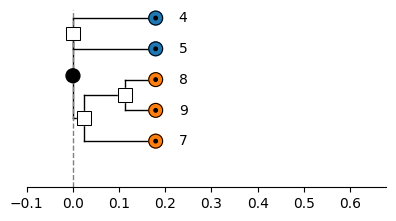

In [2]:
speciesTree, geneTree = MISC_Functions.generateTree(seed = 1,nSpecies = 2)

# get color dicts
species_colors, gene_colors = assign_colors(speciesTree, geneTree)
# visualize asymetree tree
visualize(geneTree, color_dict=gene_colors)

In [3]:
# convert to networkx
Tree = convert_to_nx(geneTree)

# Original BMG:
BMG = bmg(Tree)
BC = biccherry(BMG)
BMGBC = bmg(BC)

print(nx.utils.graphs_equal(BMG, BMGBC))

True


In [ ]:
BC2 =  MultiLayerdBICCherry(BMG,10)
BMGBC2 = bmg(BC2)

print(nx.utils.graphs_equal(BMG, BMGBC2))

[('1', {'label': 1, 'event': 'S', 'color': 1, 'tstamp': np.float64(0.17922879201600173), 'transferred': 0, 'dist': 0.0}), ('2', {'label': 2, 'event': 'D', 'color': (1, 2), 'tstamp': np.float64(0.17918794153077205), 'transferred': 0, 'dist': np.float64(4.085048522967094e-05), 'sibling_nr': 0}), ('4', {'label': 4, 'event': 'S', 'color': 2, 'tstamp': 0.0, 'transferred': 0, 'dist': np.float64(0.17918794153077205), 'sibling_nr': 0}), ('5', {'label': 5, 'event': 'S', 'color': 2, 'tstamp': 0.0, 'transferred': 0, 'dist': np.float64(0.17918794153077205), 'sibling_nr': 1}), ('3', {'label': 3, 'event': 'D', 'color': (1, 3), 'tstamp': np.float64(0.1561203530417879), 'transferred': 0, 'dist': np.float64(0.02310843897421383), 'sibling_nr': 1}), ('6', {'label': 6, 'event': 'D', 'color': (1, 3), 'tstamp': np.float64(0.06586097059343995), 'transferred': 0, 'dist': np.float64(0.09025938244834794), 'sibling_nr': 0}), ('8', {'label': 8, 'event': 'S', 'color': 3, 'tstamp': 0.0, 'transferred': 0, 'dist': np

IndexError: Cannot choose from an empty sequence

Es konnten 100 Hybride eingefügt werden, bevor die BMGs nicht mehr übereinstimmten


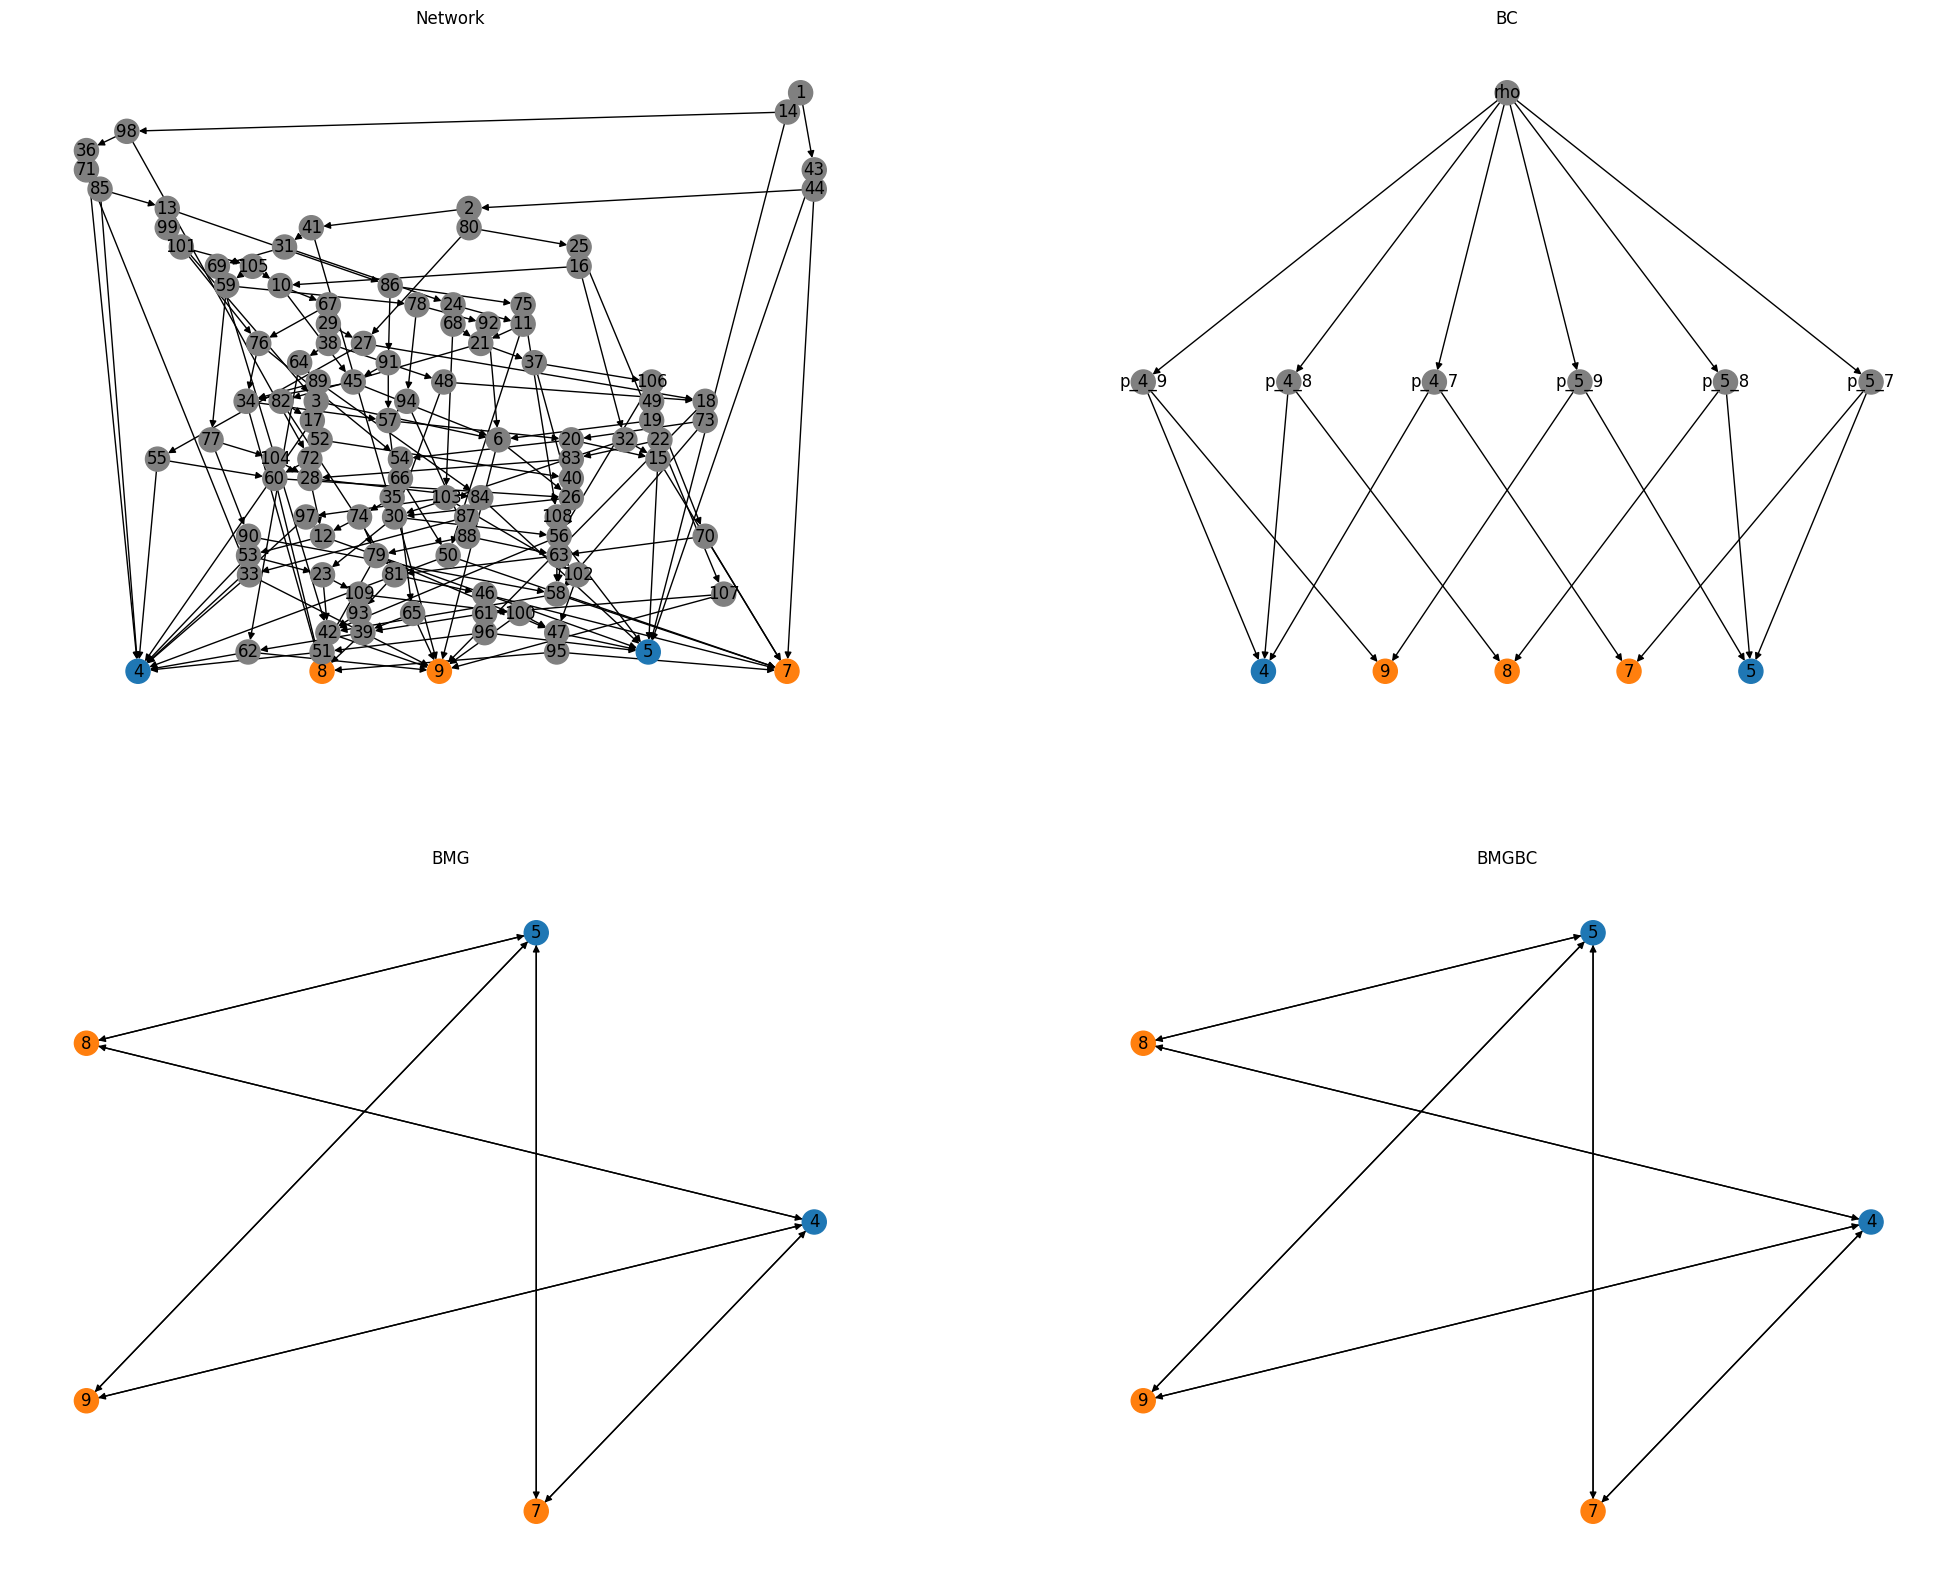

In [ ]:
# Testen, wie viele Hybride man einfügen kann, bevor die beiden BMGs nicht mehr übereinstimmen
# random.seed(6)
mode = "weak"
count = 0
Network = copy.deepcopy(Tree)
BMG = bmg(Tree)
BC = biccherry(BMG)
BMGBC = bmg(BC)

while nx.utils.graphs_equal(BMG, BMGBC) and count < 100:
    Network,combinedNodes = insertHybrid(Network)
    BMG = bmg(Network, mode = mode)
    BC = biccherry(BMG)
    BMGBC = bmg(BC, mode = mode)
    count += 1
    # if count % 10 == 0:
    #     print("Count = ",count)

    # prüfen, ob der zuletzt generierte Hybrid 2 leaves unterschiedlicher Farbe sind
    # node1 = combinedNodes[0]
    # node2 = combinedNodes[1]

    # if Network.nodes[node1]['color']!=Network.nodes[node2]['color']:
    #     print("Durch den Hybrid wurden zwei Äste unterschiedlicher Farbe direkt verbunden")

    # if Network.nodes[node1]['color']!=Network.nodes[node2]['color'] and Network.out_degree(node1) == 0 and Network.out_degree(node2) == 0:
    #     print("Durch den Hybrid wurden zwei Blätter unterschiedlicher Farbe direkt verbunden")

print("Es konnten",count,"Hybride eingefügt werden, bevor die BMGs nicht mehr übereinstimmten")


# gene color dict turn keys to strings
gene_colors_str = {str(k): v for k, v in gene_colors.items()}

# visualize tree and network
fig, axes = plt.subplots(2, 2, figsize=(25, 20))

pos = graphviz_layout(Network, prog="dot")
nodes_list = [v for v in Network.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]

nx.draw(Network, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True, ax=axes[0,0])
axes[0,0].set_title("Network")

pos = graphviz_layout(BC, prog="dot")
nodes_list = [v for v in BC.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
nx.draw(BC, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True, ax=axes[0,1])
axes[0,1].set_title("BC")


nodes_list = [v for v in BMG.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
axes[1,0].set_title("BMG")
nx.draw(BMG, nx.circular_layout(BMG), nodelist=nodes_list, node_color= nodes_colors, ax=axes[1,0], with_labels=True)


nodes_list = [v for v in BMGBC.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
axes[1,1].set_title("BMGBC")
nx.draw(BMGBC, nx.circular_layout(BMG), nodelist=nodes_list, node_color= nodes_colors, ax=axes[1,1], with_labels=True)


In [ ]:
trees = 100  # Mehrere unterschiedliche random Bäume generieren und alle testen
runs = 100
mode = "weak"
hybridsBeforeBreak = np.empty(runs)
casesWithBreak = 0
casesWithoutBreak = 0

for i in range(runs):

    count = 0
    Network = copy.deepcopy(Tree)
    BMG = bmg(Tree)
    BC = biccherry(BMG)
    BMGBC = bmg(BC)

    while nx.utils.graphs_equal(BMG, BMGBC) and count < 100:
        Network,combinedNodes = insertHybrid(Network)
        BMG = bmg(Network, mode = mode)
        BC = biccherry(BMG)
        BMGBC = bmg(BC, mode = mode)
        count += 1
    
        # prüfen, ob der zuletzt generierte Hybrid 2 leaves unterschiedlicher Farbe sind
        node1 = combinedNodes[0]
        node2 = combinedNodes[1]

        if Network.nodes[node1]['color']!=Network.nodes[node2]['color'] and Network.out_degree(node1) == 0 and Network.out_degree(node2) == 0 and nx.utils.graphs_equal(BMG, BMGBC):
            casesWithoutBreak += 1

        elif Network.out_degree(node1) > 0 and Network.out_degree(node2) == 0 and all(Network.out_degree(succ) == 0 for succ in Network.successors(node1)) and nx.utils.graphs_equal(BMG, BMGBC):

            # check ob alle Blätter die gleiche Farbe haben und ob diese Farbe unterschiedlich von node2 ist
            clrs = {Network.nodes[s].get("color") for s in Network.successors(node1)}

            if len(clrs) == 1 and Network.nodes[node2]["color"] not in clrs:
                casesWithoutBreak += 1

        elif Network.out_degree(node2) > 0 and Network.out_degree(node1) == 0 and all(Network.out_degree(succ) == 0 for succ in Network.successors(node2)) and nx.utils.graphs_equal(BMG, BMGBC):

            # check ob alle Blätter die gleiche Farbe haben und ob diese Farbe unterschiedlich von node2 ist
            clrs = {Network.nodes[s].get("color") for s in Network.successors(node2)}

            if len(clrs) == 1 and Network.nodes[node1]["color"] not in clrs:
                casesWithoutBreak += 1

    if Network.nodes[node1]['color']!=Network.nodes[node2]['color'] and Network.out_degree(node1) == 0 and Network.out_degree(node2) == 0:
        casesWithBreak += 1

    elif Network.out_degree(node1) > 0 and Network.out_degree(node2) == 0 and all(Network.out_degree(succ) == 0 for succ in Network.successors(node1)):

        # check ob alle Blätter die gleiche Farbe haben und ob diese Farbe unterschiedlich von node2 ist
        clrs = {Network.nodes[s].get("color") for s in Network.successors(node1)}

        if len(clrs) == 1 and Network.nodes[node2]["color"] not in clrs:
            casesWithBreak += 1

    elif Network.out_degree(node2) > 0 and Network.out_degree(node1) == 0 and all(Network.out_degree(succ) == 0 for succ in Network.successors(node2)):

        # check ob alle Blätter die gleiche Farbe haben und ob diese Farbe unterschiedlich von node2 ist
        clrs = {Network.nodes[s].get("color") for s in Network.successors(node2)}

        if len(clrs) == 1 and Network.nodes[node1]["color"] not in clrs:
            casesWithBreak += 1


            
    hybridsBeforeBreak[i] = count

print("average inserted Hybrids before break:",np.average(hybridsBeforeBreak))
print("Cases in which the last hybrid connected two different colored leaves directly",casesWithBreak,"and the BMGs broke")
print("There were",casesWithoutBreak,"Cases, where it didn't break the BMGs")


average inserted Hybrids before break: 69.06
Cases in which the last hybrid connected two different colored leaves directly 23 and the BMGs broke
There were 1040 Cases, where it didn't break the BMGs
